# Analisis Keputusan Bantuan UMK Menggunakan Algoritma k-Nearest Neighbors (kNN)

Notebook ini mendemonstrasikan bagaimana menerapkan algoritma **k-Nearest Neighbors (kNN)** untuk menentukan status keputusan kelayakan bantuan modal bagi tiga Usaha Mikro Kecil (UMK) baru berdasarkan data latih di `data/data.csv`.

## 1. Konsep Perhitungan Jarak kNN

Untuk mengukur kedekatan data baru dengan data latih, kita menggunakan rumus **Squared Euclidean Distance ($D^2$)**:
$$D^2 = (x_1 - q_1)^2 + (x_2 - q_2)^2 + (x_3 - q_3)^2 + (x_4 - q_4)^2$$

Di mana:
- $q_1, q_2, q_3, q_4$ adalah nilai fitur dari data uji (query).
- $x_1, x_2, x_3, x_4$ adalah nilai fitur dari data latih.

### Fitur/Atribut yang Digunakan:
- $X_1$ = Lama Usaha (tahun)
- $X_2$ = Jumlah Pekerja
- $X_3$ = Omzet (juta)
- $X_4$ = Jumlah Aset
- $Y$ = Kategori keputusan

Pada simulasi ini, kita akan menampilkan detail perhitungan rumus jarak per baris data latih, diurutkan sesuai dengan urutan asli dataset, serta menyembunyikan kategori keputusan untuk baris yang bukan merupakan tetangga terdekat (dilambangkan dengan `-`), sesuai format lembar perhitungan tugas.

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Set style sebaran
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

print("Library berhasil diimpor.")

Library berhasil diimpor.


In [17]:
# Load data latih
train_df = pd.read_csv('data/data.csv')
print(f"Data Latih ({train_df.shape[0]} baris):")
display(train_df)

Data Latih (16 baris):


,Nama_UKM,Lama_Usaha,Jumlah_Pekerja,Omzet,Jumlah_Aset,Hasil_Keputusan
0,Sanggar Azalea,2,14,3,2,TUNDA
1,Kedurus Sejahtera,6,7,5,4,TIDAK
2,Rapi Ayu Handycraft,4,16,1,10,TUNDA
3,Jaya Komputer,2,9,2,2,TUNDA
4,Purnama,1,9,5,4,TUNDA
5,Kencana Craft,3,22,2,1,TUNDA
6,V-Tri Accessories,4,14,2,3,TIDAK
7,Maju Jaya Sablon,5,1,3,2,YA
8,Batik Semanggi,6,1,2,3,YA
9,Sunrise Picture,7,13,5,10,TIDAK


In [18]:
# Definisikan data uji (query)
test_data = [
    {"Nama_UKM": "Umk Pamurbaya", "Lama_Usaha": 4, "Jumlah_Pekerja": 15, "Omzet": 4, "Jumlah_Aset": 6},
    {"Nama_UKM": "Umk Bandeng", "Lama_Usaha": 3, "Jumlah_Pekerja": 28, "Omzet": 4, "Jumlah_Aset": 10},
    {"Nama_UKM": "Bukid Graffer", "Lama_Usaha": 2, "Jumlah_Pekerja": 12, "Omzet": 1, "Jumlah_Aset": 3}
]

features = ["Lama_Usaha", "Jumlah_Pekerja", "Omzet", "Jumlah_Aset"]
target_col = "Hasil_Keputusan"

print("Data Uji:")
display(pd.DataFrame(test_data))

Data Uji:


,Nama_UKM,Lama_Usaha,Jumlah_Pekerja,Omzet,Jumlah_Aset
0,Umk Pamurbaya,4,15,4,6
1,Umk Bandeng,3,28,4,10
2,Bukid Graffer,2,12,1,3


In [19]:
def run_knn_step_by_step(train_df, q, k=3):
    q_val = np.array([q[f] for f in features])
    df = train_df.copy()
    
    # Hitung Jarak Kuadrat
    sq_dists = []
    for _, row in df.iterrows():
        x_val = row[features].values.astype(float)
        sq_d = np.sum((x_val - q_val) ** 2)
        sq_dists.append(sq_d)
        
    df['Square_Distance'] = sq_dists
    df['Original_Index'] = df.index
    
    # Urutkan secara stabil untuk menentukan rank
    sorted_df = df.sort_values(by=['Square_Distance', 'Original_Index']).reset_index(drop=True)
    sorted_df['Jarak_Terkecil_Rank'] = sorted_df.index + 1
    
    # Kembalikan ke urutan asli data latih
    df = sorted_df.sort_values(by='Original_Index').reset_index(drop=True)
    
    # Konstruksi visualisasi rumus
    formulas = []
    for _, row in df.iterrows():
        parts = []
        for f_name, q_v in zip(features, q_val):
            parts.append(f"({int(row[f_name])}-{int(q_v)})^2")
        expr = " + ".join(parts)
        formulas.append(f"{expr} = {int(row['Square_Distance'])}")
        
    df['Formula_Expr'] = formulas
    return df, sorted_df

## 2. Simulasi Lembar Perhitungan Jarak & Voting (k=3)

In [20]:
k_val = 3

for q in test_data:
    q_name = q["Nama_UKM"]
    df_processed, df_sorted = run_knn_step_by_step(train_df, q, k_val)
    
    # Tampilkan Panel Profil
    display(HTML(f"""
    <div style='background: linear-gradient(135deg, #1e293b, #334155); color: #f8fafc; padding: 15px; border-radius: 12px; margin-top: 25px;'>
        <h3 style='margin: 0; font-weight: 800; font-family: sans-serif; font-size: 1.25rem; letter-spacing: -0.025em;'>ANALISIS kNN: {q_name.upper()}</h3>
        <p style='margin: 5px 0 0 0; opacity: 0.8; font-size: 0.95rem;'>
            Data Query (q1, q2, q3, q4) = ({q['Lama_Usaha']}, {q['Jumlah_Pekerja']}, {q['Omzet']}, {q['Jumlah_Aset']})
        </p>
    </div>
    """))
    
    # Voting Mayoritas
    nn_df = df_sorted.head(k_val)
    votes = nn_df[target_col].value_counts().to_dict()
    max_votes = max(votes.values())
    candidates = [label for label, count in votes.items() if count == max_votes]
    
    if len(candidates) > 1:
        # Ambil yang rank terkecil
        resolved = None
        for _, row_nn in nn_df.iterrows():
            if row_nn[target_col] in candidates:
                resolved = row_nn[target_col]
                break
        decision = resolved
        note = " (Resolusi Seri: Mengambil tetangga terdekat)"
    else:
        decision = candidates[0]
        note = ""
        
    color_map = {'YA': '#10b981', 'TIDAK': '#ef4444', 'TUNDA': '#f59e0b'}
    color = color_map.get(decision, '#3b82f6')
    
    display(HTML(f"""
    <div style='margin: 10px 0; font-size: 1.05rem;'>
        <strong>Keputusan Akhir (k={k_val}):</strong> 
        <span style='color: {color}; font-weight: 800; padding: 3px 10px; background: {color}1a; border-radius: 6px;'>{decision}</span>
        <span style='color: #64748b; font-size: 0.9em; margin-left: 10px;'>Voting Terbanyak: {votes}{note}</span>
    </div>
    """))
    
    # Bangun Dataframe Tampilan Lembar Tugas
    q_val_str = f"{q['Lama_Usaha']},{q['Jumlah_Pekerja']},{q['Omzet']},{q['Jumlah_Aset']}"
    table_df = pd.DataFrame()
    table_df['Nama UKM'] = df_processed['Nama_UKM']
    table_df['X1 = Lama Usaha (tahun)'] = df_processed['Lama_Usaha']
    table_df['X2 = Jumlah Pekerja'] = df_processed['Jumlah_Pekerja']
    table_df['X3 = Omzet (juta)'] = df_processed['Omzet']
    table_df['X4 = Jumlah Aset'] = df_processed['Jumlah_Aset']
    table_df[f'Square distance to query distance ({q_val_str})'] = df_processed['Formula_Expr']
    table_df['Jarak Terkecil'] = df_processed['Jarak_Terkecil_Rank']
    table_df['Apakah termasuk nearest neighbor (K)'] = df_processed['Jarak_Terkecil_Rank'].apply(
        lambda r: 'Ya' if r <= k_val else 'Tidak'
    )
    table_df['Y = kategori nearest neighbor'] = df_processed.apply(
        lambda r: r[target_col] if r['Jarak_Terkecil_Rank'] <= k_val else '-', axis=1
    )
    
    # Render tabel dengan gaya visual lembar tugas
    display_html = (
        table_df.style
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'font-family': 'sans-serif', 'font-size': '12px'})
        .set_properties(subset=['Nama UKM'], **{'text-align': 'left', 'font-weight': 'bold'})
        .set_properties(subset=[f'Square distance to query distance ({q_val_str})'], **{'font-family': 'monospace', 'text-align': 'left', 'font-size': '11px', 'color': '#334155'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#475569'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px'), ('font-size', '12px')]},
            {'selector': 'td', 'props': [('padding', '6px'), ('border-bottom', '1px solid #cbd5e1')]} 
        ])
        .apply(lambda x: ['background-color: #dbeafe; font-weight: bold' if df_processed.loc[i, 'Jarak_Terkecil_Rank'] <= k_val else '' for i, _ in enumerate(x)], axis=0, subset=['Apakah termasuk nearest neighbor (K)'])
        .apply(lambda x: ['background-color: #dbeafe; font-weight: bold; color: ' + color_map.get(df_processed.loc[i, target_col], '#000') if df_processed.loc[i, 'Jarak_Terkecil_Rank'] <= k_val else '' for i, _ in enumerate(x)], axis=0, subset=['Y = kategori nearest neighbor'])
    )
    display(display_html)

Nama UKM,X1 = Lama Usaha (tahun),X2 = Jumlah Pekerja,X3 = Omzet (juta),X4 = Jumlah Aset,"Square distance to query distance (4,15,4,6)",Jarak Terkecil,Apakah termasuk nearest neighbor (K),Y = kategori nearest neighbor
Sanggar Azalea,2,14,3,2,(2-4)^2 + (14-15)^2 + (3-4)^2 + (2-6)^2 = 22,5,Tidak,-
Kedurus Sejahtera,6,7,5,4,(6-4)^2 + (7-15)^2 + (5-4)^2 + (4-6)^2 = 73,10,Tidak,-
Rapi Ayu Handycraft,4,16,1,10,(4-4)^2 + (16-15)^2 + (1-4)^2 + (10-6)^2 = 26,6,Tidak,-
Jaya Komputer,2,9,2,2,(2-4)^2 + (9-15)^2 + (2-4)^2 + (2-6)^2 = 60,9,Tidak,-
Purnama,1,9,5,4,(1-4)^2 + (9-15)^2 + (5-4)^2 + (4-6)^2 = 50,8,Tidak,-
Kencana Craft,3,22,2,1,(3-4)^2 + (22-15)^2 + (2-4)^2 + (1-6)^2 = 79,11,Tidak,-
V-Tri Accessories,4,14,2,3,(4-4)^2 + (14-15)^2 + (2-4)^2 + (3-6)^2 = 14,2,Ya,TIDAK
Maju Jaya Sablon,5,1,3,2,(5-4)^2 + (1-15)^2 + (3-4)^2 + (2-6)^2 = 214,16,Tidak,-
Batik Semanggi,6,1,2,3,(6-4)^2 + (1-15)^2 + (2-4)^2 + (3-6)^2 = 213,15,Tidak,-
Sunrise Picture,7,13,5,10,(7-4)^2 + (13-15)^2 + (5-4)^2 + (10-6)^2 = 30,7,Tidak,-


Nama UKM,X1 = Lama Usaha (tahun),X2 = Jumlah Pekerja,X3 = Omzet (juta),X4 = Jumlah Aset,"Square distance to query distance (3,28,4,10)",Jarak Terkecil,Apakah termasuk nearest neighbor (K),Y = kategori nearest neighbor
Sanggar Azalea,2,14,3,2,(2-3)^2 + (14-28)^2 + (3-4)^2 + (2-10)^2 = 262,10,Tidak,-
Kedurus Sejahtera,6,7,5,4,(6-3)^2 + (7-28)^2 + (5-4)^2 + (4-10)^2 = 487,13,Tidak,-
Rapi Ayu Handycraft,4,16,1,10,(4-3)^2 + (16-28)^2 + (1-4)^2 + (10-10)^2 = 154,5,Tidak,-
Jaya Komputer,2,9,2,2,(2-3)^2 + (9-28)^2 + (2-4)^2 + (2-10)^2 = 430,12,Tidak,-
Purnama,1,9,5,4,(1-3)^2 + (9-28)^2 + (5-4)^2 + (4-10)^2 = 402,11,Tidak,-
Kencana Craft,3,22,2,1,(3-3)^2 + (22-28)^2 + (2-4)^2 + (1-10)^2 = 121,4,Tidak,-
V-Tri Accessories,4,14,2,3,(4-3)^2 + (14-28)^2 + (2-4)^2 + (3-10)^2 = 250,9,Tidak,-
Maju Jaya Sablon,5,1,3,2,(5-3)^2 + (1-28)^2 + (3-4)^2 + (2-10)^2 = 798,16,Tidak,-
Batik Semanggi,6,1,2,3,(6-3)^2 + (1-28)^2 + (2-4)^2 + (3-10)^2 = 791,15,Tidak,-
Sunrise Picture,7,13,5,10,(7-3)^2 + (13-28)^2 + (5-4)^2 + (10-10)^2 = 242,8,Tidak,-


Nama UKM,X1 = Lama Usaha (tahun),X2 = Jumlah Pekerja,X3 = Omzet (juta),X4 = Jumlah Aset,"Square distance to query distance (2,12,1,3)",Jarak Terkecil,Apakah termasuk nearest neighbor (K),Y = kategori nearest neighbor
Sanggar Azalea,2,14,3,2,(2-2)^2 + (14-12)^2 + (3-1)^2 + (2-3)^2 = 9,1,Ya,TUNDA
Kedurus Sejahtera,6,7,5,4,(6-2)^2 + (7-12)^2 + (5-1)^2 + (4-3)^2 = 58,6,Tidak,-
Rapi Ayu Handycraft,4,16,1,10,(4-2)^2 + (16-12)^2 + (1-1)^2 + (10-3)^2 = 69,8,Tidak,-
Jaya Komputer,2,9,2,2,(2-2)^2 + (9-12)^2 + (2-1)^2 + (2-3)^2 = 11,3,Ya,TUNDA
Purnama,1,9,5,4,(1-2)^2 + (9-12)^2 + (5-1)^2 + (4-3)^2 = 27,5,Tidak,-
Kencana Craft,3,22,2,1,(3-2)^2 + (22-12)^2 + (2-1)^2 + (1-3)^2 = 106,12,Tidak,-
V-Tri Accessories,4,14,2,3,(4-2)^2 + (14-12)^2 + (2-1)^2 + (3-3)^2 = 9,2,Ya,TIDAK
Maju Jaya Sablon,5,1,3,2,(5-2)^2 + (1-12)^2 + (3-1)^2 + (2-3)^2 = 135,13,Tidak,-
Batik Semanggi,6,1,2,3,(6-2)^2 + (1-12)^2 + (2-1)^2 + (3-3)^2 = 138,14,Tidak,-
Sunrise Picture,7,13,5,10,(7-2)^2 + (13-12)^2 + (5-1)^2 + (10-3)^2 = 91,10,Tidak,-


## 3. Visualisasi Grafik Distribusi Data UMK

Mari kita gambarkan sebaran titik data latih berdasarkan atribut **Jumlah Pekerja** dan **Jumlah Aset**, serta posisi dari tiga titik data uji (query) baru.

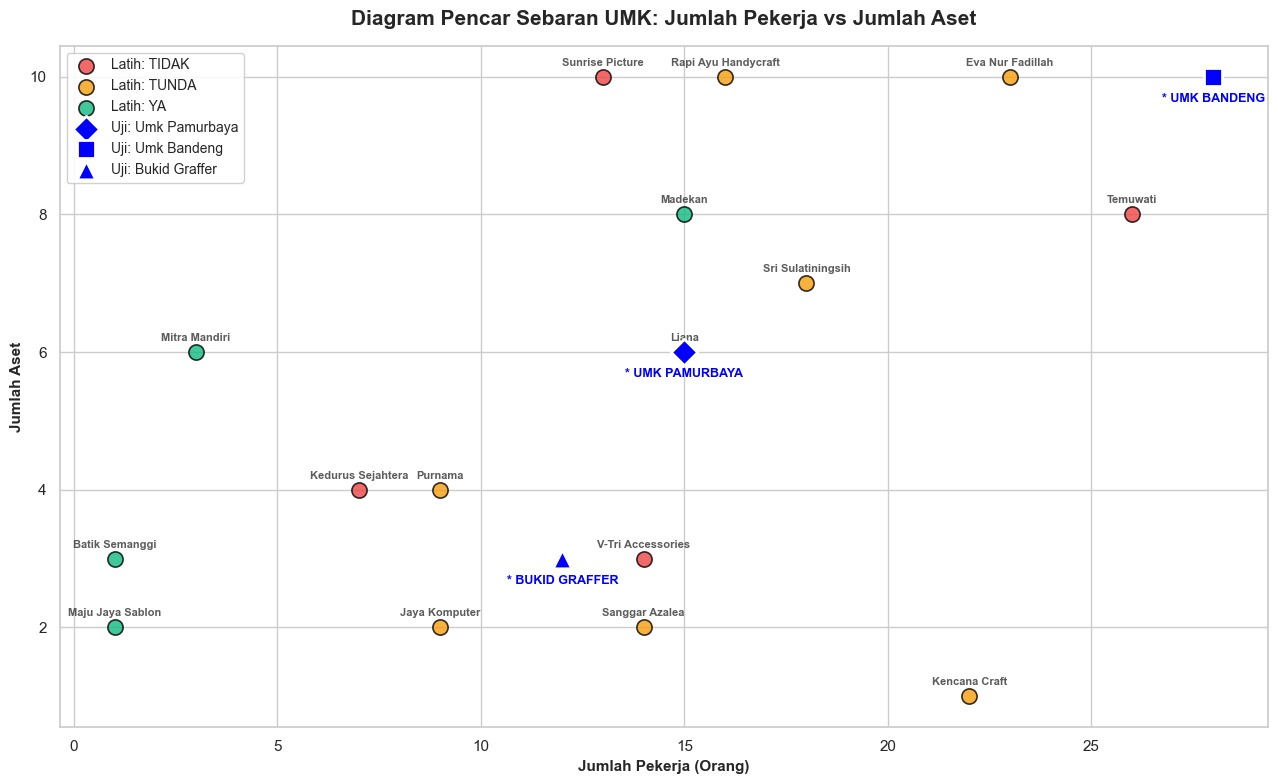

In [21]:
plt.figure(figsize=(13, 8))

# Sebaran data latih berdasarkan keputusan
colors = {'YA': '#10b981', 'TIDAK': '#ef4444', 'TUNDA': '#f59e0b'}
for label, group in train_df.groupby('Hasil_Keputusan'):
    plt.scatter(
        group['Jumlah_Pekerja'], 
        group['Jumlah_Aset'], 
        label=f"Latih: {label}",
        color=colors[label],
        s=120, 
        alpha=0.8, 
        edgecolors='black',
        linewidths=1.2
    )
    for _, row in group.iterrows():
        plt.annotate(
            row['Nama_UKM'], 
            (row['Jumlah_Pekerja'], row['Jumlah_Aset']),
            textcoords="offset points", 
            xytext=(0,8), 
            ha='center',
            fontsize=8,
            alpha=0.75,
            weight='bold'
        )

# Sebaran data uji
markers = ['D', 's', '^']
for i, q in enumerate(test_data):
    plt.scatter(
        q['Jumlah_Pekerja'], 
        q['Jumlah_Aset'], 
        label=f"Uji: {q['Nama_UKM']}", 
        color='blue', 
        marker=markers[i], 
        s=180, 
        edgecolors='white', 
        linewidths=2.0,
        zorder=5
    )
    plt.annotate(
        f"* {q['Nama_UKM'].upper()}", 
        (q['Jumlah_Pekerja'], q['Jumlah_Aset']),
        textcoords="offset points", 
        xytext=(0,-18), 
        ha='center',
        color='blue',
        fontsize=9,
        weight='bold',
        zorder=6
    )

plt.title('Diagram Pencar Sebaran UMK: Jumlah Pekerja vs Jumlah Aset', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Jumlah Pekerja (Orang)', fontsize=11, fontweight='bold')
plt.ylabel('Jumlah Aset', fontsize=11, fontweight='bold')
plt.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=10, loc='best')
plt.tight_layout()
plt.show()